# TCN-MLP (Lightweight - 9 Climate Features) - Trimmed Training Notebook

This notebook contains only the minimal code to run the 5-fold train/test training, ensemble voting, and the final summary.

In [1]:
# Imports and reproducibility
import os
import random
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, Model, Input, optimizers
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('Imports ready. Seed set to', SEED)

Imports ready. Seed set to 42


In [ ]:
# Load processed dataset and build climate sequences (9 features)
DATA_PATH = '../data/processed_dataset.csv'
df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=['Yield_kg_per_ha']).copy()

climate_features = [
    'T2M', 'T2M_MAX', 'T2M_MIN', 'TS', 'T2MDEW', 'T2MWET', 'PRECTOTCORR', 'RH2M', 'QV2M'
]
"""
Category,       Parameter_Code, Parameter_Name,         Unit
temperature,    T2M,            Mean temperature at 2m, °C
temperature,    T2M_MAX,        Max temperature at 2m,  °C
temperature,    T2M_MIN,        Min temperature at 2m,  °C
temperature,    TS,             land surface temperature,°C
rainfall,       PRECTOTCORR,    Bias-corrected total precipitation,mm/day
humidity,       RH2M,           Relative humidity at 2m,%
humidity,       QV2M,           Specific humidity at 2m,g/kg
humidity,       T2MDEW,         Dew point temperature at 2m,°C
humidity,       T2MWET,         Wet bulb temperature at 2m,°C
"""
n_features = len(climate_features)
n_months = 12

# Build X_seq tensor
X_seq = np.zeros((df.shape[0], n_months, n_features), dtype=np.float32)
for m in range(1, n_months + 1):
    for i, feat in enumerate(climate_features):
        X_seq[:, m - 1, i] = df[f'{feat}_m{m}'].values

y_raw = df['Yield_kg_per_ha'].values.astype(np.float32)
years = df['Year'].values.astype(np.float32)
region_to_id = {r: i for i, r in enumerate(sorted(df['Region'].unique()))}
crop_to_id = {c: i for i, c in enumerate(sorted(df['Crop'].unique()))}
region_ids = np.array([region_to_id[r] for r in df['Region'].values], dtype=np.int32)
crop_ids = np.array([crop_to_id[c] for c in df['Crop'].values], dtype=np.int32)

print('Built X_seq with shape:', X_seq.shape)
print('Dataset samples:', df.shape[0])

Built X_seq with shape: (600, 12, 9)
Dataset samples: 600


In [4]:
# Stratified labels and year/context feature builder
epsilon = 1e-6
y_log = np.log(y_raw + epsilon)
strat_labels = np.array([f'{c}_{r}' for c, r in zip(crop_ids, region_ids)])
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def build_year_features(year_values, reg_ids, crp_ids, n_regions=None, n_crops=None):
    if n_regions is None: n_regions = len(np.unique(reg_ids))
    if n_crops is None: n_crops = len(np.unique(crp_ids))
    y_norm = ((year_values.reshape(-1, 1) - 1999.0) / 24.0).astype(np.float32)
    y_sin = np.sin(2.0 * np.pi * y_norm).astype(np.float32)
    y_cos = np.cos(2.0 * np.pi * y_norm).astype(np.float32)
    reg_onehot = np.zeros((len(year_values), n_regions), dtype=np.float32)
    for i in range(n_regions):
        reg_onehot[:, i] = (reg_ids == i).astype(np.float32)
    crop_onehot = np.zeros((len(year_values), n_crops), dtype=np.float32)
    for i in range(n_crops):
        crop_onehot[:, i] = (crp_ids == i).astype(np.float32)
    return np.column_stack([y_norm, y_sin, y_cos, reg_onehot, crop_onehot]).astype(np.float32)

print('Prepared stratified labels and year feature builder')

Prepared stratified labels and year feature builder


In [5]:
# Model definition (TCN-MLP)
def build_model(n_regions, n_crops, n_year_features, n_features, l2_reg=1e-3, dropout=0.12, lr=3e-4, weight_decay=3e-4):
    sequence_input = Input(shape=(12, n_features), name='sequence_input')
    region_input = Input(shape=(1,), dtype='int32', name='region_input')
    crop_input = Input(shape=(1,), dtype='int32', name='crop_input')
    year_input = Input(shape=(n_year_features,), name='year_input')
    x = layers.Conv1D(48, kernel_size=3, padding='causal', activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(sequence_input)
    x = layers.BatchNormalization(momentum=0.95, epsilon=1e-3)(x)
    x = layers.Dropout(dropout)(x)
    x_dil1 = layers.Conv1D(48, kernel_size=3, padding='causal', activation='relu', dilation_rate=2, kernel_regularizer=regularizers.l2(l2_reg))(x)
    x_dil1 = layers.BatchNormalization(momentum=0.95, epsilon=1e-3)(x_dil1)
    x_dil1 = layers.Dropout(dropout)(x_dil1)
    x = layers.Add()([x, x_dil1])
    x_dil2 = layers.Conv1D(48, kernel_size=3, padding='causal', activation='relu', dilation_rate=4, kernel_regularizer=regularizers.l2(l2_reg))(x)
    x_dil2 = layers.BatchNormalization(momentum=0.95, epsilon=1e-3)(x_dil2)
    x_dil2 = layers.Dropout(dropout)(x_dil2)
    x = layers.Add()([x, x_dil2])
    x = layers.Conv1D(32, kernel_size=1, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(x)
    x_mean = layers.GlobalAveragePooling1D()(x)
    x_max = layers.GlobalMaxPooling1D()(x)
    x_tcn = layers.Concatenate()([x_mean, x_max])
    region_emb = layers.Embedding(input_dim=n_regions, output_dim=4)(region_input)
    region_emb = layers.Flatten()(region_emb)
    crop_emb = layers.Embedding(input_dim=n_crops, output_dim=4)(crop_input)
    crop_emb = layers.Flatten()(crop_emb)
    year_branch = layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(year_input)
    year_branch = layers.Dropout(dropout)(year_branch)
    merged = layers.Concatenate()([x_tcn, region_emb, crop_emb, year_branch])
    dense_1 = layers.Dense(40, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(merged)
    dense_1 = layers.BatchNormalization(momentum=0.95, epsilon=1e-3)(dense_1)
    dense_1 = layers.Dropout(dropout)(dense_1)
    dense_2 = layers.Dense(20, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(dense_1)
    dense_2 = layers.Dropout(dropout)(dense_2)
    output = layers.Dense(1, activation='linear')(dense_2)
    model = Model(inputs=[sequence_input, region_input, crop_input, year_input], outputs=output)
    optimizer = optimizers.AdamW(learning_rate=lr, weight_decay=weight_decay, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss=tf.keras.losses.Huber(delta=0.35), metrics=['mae'])
    return model

print('Model builder ready')

Model builder ready


In [14]:
# Run 5-fold CV with train/test splits and store models for ensemble
n_folds = 5
fold_models = {}
fold_predictions = {}
best_fold_test_r2 = -np.inf
best_fold = -1
best_model_path = '../models/best_fold_model.keras'

for fold, (train_idx, test_idx) in enumerate(skf.split(X_seq, strat_labels), start=1):
    print(f'\n===== Fold {fold}/{n_folds} =====')
    X_train_raw = X_seq[train_idx]
    X_test_raw = X_seq[test_idx]
    y_train_log = y_log[train_idx]
    y_test_log = y_log[test_idx]
    y_train_raw = y_raw[train_idx]
    y_test_raw = y_raw[test_idx]
    r_train = region_ids[train_idx]
    r_test = region_ids[test_idx]
    c_train = crop_ids[train_idx]
    c_test = crop_ids[test_idx]
    yr_train_raw = build_year_features(years[train_idx], r_train, c_train, n_regions=len(region_to_id), n_crops=len(crop_to_id))
    yr_test_raw = build_year_features(years[test_idx], r_test, c_test, n_regions=len(region_to_id), n_crops=len(crop_to_id))
    x_scaler = StandardScaler()
    X_train = x_scaler.fit_transform(X_train_raw.reshape(-1, n_features)).reshape(X_train_raw.shape).astype(np.float32)
    X_test = x_scaler.transform(X_test_raw.reshape(-1, n_features)).reshape(X_test_raw.shape).astype(np.float32)
    year_scaler = StandardScaler()
    yr_train = year_scaler.fit_transform(yr_train_raw).astype(np.float32)
    yr_test = year_scaler.transform(yr_test_raw).astype(np.float32)
    n_crops = len(crop_to_id)
    crop_log_mean = np.zeros(n_crops, dtype=np.float32)
    crop_log_std = np.zeros(n_crops, dtype=np.float32)
    for cid in range(n_crops):
        mask = c_train == cid
        vals = y_train_log[mask]
        crop_log_mean[cid] = np.mean(vals)
        crop_log_std[cid] = max(np.std(vals), 1e-3)
    y_train_norm = (y_train_log - crop_log_mean[c_train]) / crop_log_std[c_train]
    y_test_norm = (y_test_log - crop_log_mean[c_test]) / crop_log_std[c_test]
    fold_model = build_model(n_regions=len(region_to_id), n_crops=len(crop_to_id), n_year_features=yr_train.shape[1], n_features=n_features)
    fold_callbacks = [keras.callbacks.ReduceLROnPlateau(monitor='loss', factor=0.5, patience=15, min_lr=1e-5, verbose=1)]
    history = fold_model.fit([X_train, r_train, c_train, yr_train], y_train_norm, epochs=160, batch_size=32, callbacks=fold_callbacks, verbose=1)
    train_pred_norm = fold_model.predict([X_train, r_train, c_train, yr_train], verbose=0).ravel()
    train_pred_log = train_pred_norm * crop_log_std[c_train] + crop_log_mean[c_train]
    yhat_train = np.exp(train_pred_log)
    test_pred_norm = fold_model.predict([X_test, r_test, c_test, yr_test], verbose=0).ravel()
    test_pred_log = test_pred_norm * crop_log_std[c_test] + crop_log_mean[c_test]
    yhat_test = np.exp(test_pred_log)
    fold_models[fold] = fold_model
    fold_predictions[fold] = {'y_test_raw': y_test_raw, 'test_pred_norm': test_pred_norm, 'r_test': r_test, 'c_test': c_test, 'yr_test': yr_test, 'X_test': X_test, 'crop_log_mean': crop_log_mean, 'crop_log_std': crop_log_std}
    # compute test R² to track best fold
    test_r2_fold = r2_score(y_test_raw, yhat_test)
    if test_r2_fold > best_fold_test_r2:
        best_fold_test_r2 = test_r2_fold
        best_fold = fold
        fold_model.save(best_model_path)
    print(f"Completed Fold {fold}: Test R²={test_r2_fold:.4f}")

print('CV training completed. (ensemble-only reporting)')


===== Fold 1/5 =====
Epoch 1/160
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - loss: 0.5818 - mae: 1.1236 - learning_rate: 3.0000e-04
Epoch 2/160
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.5379 - mae: 1.0018 - learning_rate: 3.0000e-04
Epoch 3/160
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.5104 - mae: 0.9243 - learning_rate: 3.0000e-04
Epoch 4/160
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.4905 - mae: 0.8703 - learning_rate: 3.0000e-04
Epoch 5/160
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.4733 - mae: 0.8235 - learning_rate: 3.0000e-04
Epoch 6/160
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.4891 - mae: 0.8731 - learning_rate: 3.0000e-04
Epoch 7/160
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.4756 - mae: 0.8354 - learning_rate: 3.0000e-04
Epoch 8/160
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.4709 - mae: 0.8257 - learning_rate: 3.0000e-04
Epoch 9/160
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.4682 - mae: 0.8185 - learning_rate: 3.0000e

In [12]:
# Ensemble: average predictions from all fold models on each fold's test set
ensemble_metrics = []
for fold in range(1, n_folds + 1):
    preds = fold_predictions[fold]
    y_test_raw = preds['y_test_raw']
    ensemble_pred_norms = []
    for other_fold in range(1, n_folds + 1):
        other_model = fold_models[other_fold]
        other_pred_norm = other_model.predict([preds['X_test'], preds['r_test'], preds['c_test'], preds['yr_test']], verbose=0).ravel()
        ensemble_pred_norms.append(other_pred_norm)
    ensemble_pred_norm = np.mean(ensemble_pred_norms, axis=0)
    ensemble_pred_log = ensemble_pred_norm * preds['crop_log_std'][preds['c_test']] + preds['crop_log_mean'][preds['c_test']]
    ensemble_yhat = np.exp(ensemble_pred_log)
    ensemble_r2 = r2_score(y_test_raw, ensemble_yhat)
    ensemble_mae = mean_absolute_error(y_test_raw, ensemble_yhat)
    # compute MAPE instead of RMSE
    ensemble_mape = np.mean(np.abs((y_test_raw - ensemble_yhat) / y_test_raw)) * 100
    ensemble_metrics.append({'Fold': fold, 'Ensemble_R2': ensemble_r2, 'Ensemble_MAE': ensemble_mae, 'Ensemble_MAPE': ensemble_mape})

ensemble_df = pd.DataFrame(ensemble_metrics)
print('Ensemble completed. (RMSE removed; MAPE included)')

Ensemble completed. (RMSE removed; MAPE included)


In [15]:
# Save results and show concise final metrics (ensemble-only)
print('Training and ensemble metrics complete.')
print('\nENSEMBLE TEST RESULTS:')
print(ensemble_df.to_string(index=False))

Training and ensemble metrics complete.

ENSEMBLE TEST RESULTS:
 Fold  Ensemble_R2  Ensemble_MAE  Ensemble_MAPE
    1     0.814856    624.670593       9.487693
    2     0.927205    583.669373      11.631229
    3     0.957875    568.191467      10.047669
    4     0.854096    727.674683       9.438344
    5     0.765352    729.510315       9.382128


In [17]:
# Ensemble-only: compute MAPE and per-crop ensemble metrics (no individual metrics)

def compute_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print('\n' + '='*80)
print('ENSEMBLE-ONLY METRICS (with MAPE)'.center(80))
print('='*80)

ensemble_mape_list = []
ensemble_all_y_true = []
ensemble_all_y_pred = []

for fold in range(1, n_folds + 1):
    preds = fold_predictions[fold]
    y_test_raw = preds['y_test_raw']
    c_test = preds['c_test']

    # Build ensemble predictions (average of all fold models)
    ensemble_pred_norms = []
    for other_fold in range(1, n_folds + 1):
        other_model = fold_models[other_fold]
        other_pred_norm = other_model.predict([preds['X_test'], preds['r_test'], preds['c_test'], preds['yr_test']], verbose=0).ravel()
        ensemble_pred_norms.append(other_pred_norm)
    ensemble_pred_norm = np.mean(ensemble_pred_norms, axis=0)

    # Denormalize back to yield units
    ensemble_pred_log = ensemble_pred_norm * preds['crop_log_std'][c_test] + preds['crop_log_mean'][c_test]
    ensemble_yhat = np.exp(ensemble_pred_log)

    r2 = r2_score(y_test_raw, ensemble_yhat)
    mae = mean_absolute_error(y_test_raw, ensemble_yhat)
    mape = compute_mape(y_test_raw, ensemble_yhat)

    ensemble_mape_list.append({'Fold': fold, 'Ensemble_R2': r2, 'Ensemble_MAE': mae, 'Ensemble_MAPE': mape})

    # accumulate for per-crop aggregation
    ensemble_all_y_true.append((c_test, y_test_raw))
    ensemble_all_y_pred.append((c_test, ensemble_yhat))

    print(f"Fold {fold}: R²={r2:.4f} | MAE={mae:.2f} kg/ha | MAPE={mape:.2f}%")

ensemble_mape_df = pd.DataFrame(ensemble_mape_list)
print(f"\nEnsemble Average: R²={ensemble_mape_df['Ensemble_R2'].mean():.4f} | MAE={ensemble_mape_df['Ensemble_MAE'].mean():.2f} | MAPE={ensemble_mape_df['Ensemble_MAPE'].mean():.2f}%")

# Per-crop ensemble metrics aggregated across folds
print('\n' + '='*80)
print('PER-CROP ENSEMBLE PERFORMANCE (Aggregated Across All Folds)'.center(80))
print('='*80)

id_to_crop = {v: k for k, v in crop_to_id.items()}

crop_results = []
for cid, crop_name in id_to_crop.items():
    ys_true = []
    ys_pred = []
    for (c_test_arr, y_true_arr), (c_test_arr2, y_pred_arr) in zip(ensemble_all_y_true, ensemble_all_y_pred):
        # c_test_arr is array of crop ids per sample in that fold
        mask = c_test_arr == cid
        if np.any(mask):
            ys_true.extend(y_true_arr[mask])
            ys_pred.extend(y_pred_arr[mask])
    if ys_true:
        ys_true = np.array(ys_true)
        ys_pred = np.array(ys_pred)
        r2 = r2_score(ys_true, ys_pred)
        mae = mean_absolute_error(ys_true, ys_pred)
        mape = compute_mape(ys_true, ys_pred)
        crop_results.append({'Crop': crop_name, 'Ens_R2': r2, 'Ens_MAE': mae, 'Ens_MAPE': mape})

crop_perf_df = pd.DataFrame(crop_results)
print(crop_perf_df.to_string(index=False))

# Save ensemble-only CSVs
ensemble_mape_df.to_csv('../results/ensemble_mape_only_trimmed.csv', index=False)
crop_perf_df.to_csv('../results/per_crop_ensemble_only_trimmed.csv', index=False)

print('\n' + '='*80)
print('✓ Ensemble-only metrics saved to CSV files')
print('='*80)


                       ENSEMBLE-ONLY METRICS (with MAPE)                        
Fold 1: R²=0.8200 | MAE=603.90 kg/ha | MAPE=9.07%
Fold 2: R²=0.9345 | MAE=568.11 kg/ha | MAPE=10.98%
Fold 3: R²=0.9594 | MAE=560.79 kg/ha | MAPE=9.85%
Fold 4: R²=0.8505 | MAE=732.54 kg/ha | MAPE=9.40%
Fold 5: R²=0.7692 | MAE=737.36 kg/ha | MAPE=9.48%

Ensemble Average: R²=0.8667 | MAE=640.54 | MAPE=9.76%

          PER-CROP ENSEMBLE PERFORMANCE (Aggregated Across All Folds)           
   Crop   Ens_R2     Ens_MAE  Ens_MAPE
Cassava 0.682948 1129.567505 10.933689
  Maize 0.551646  146.917084  8.243858
   Rice 0.453659  198.367996  9.670739
    Yam 0.476357 1087.308960 10.181231

✓ Ensemble-only metrics saved to CSV files


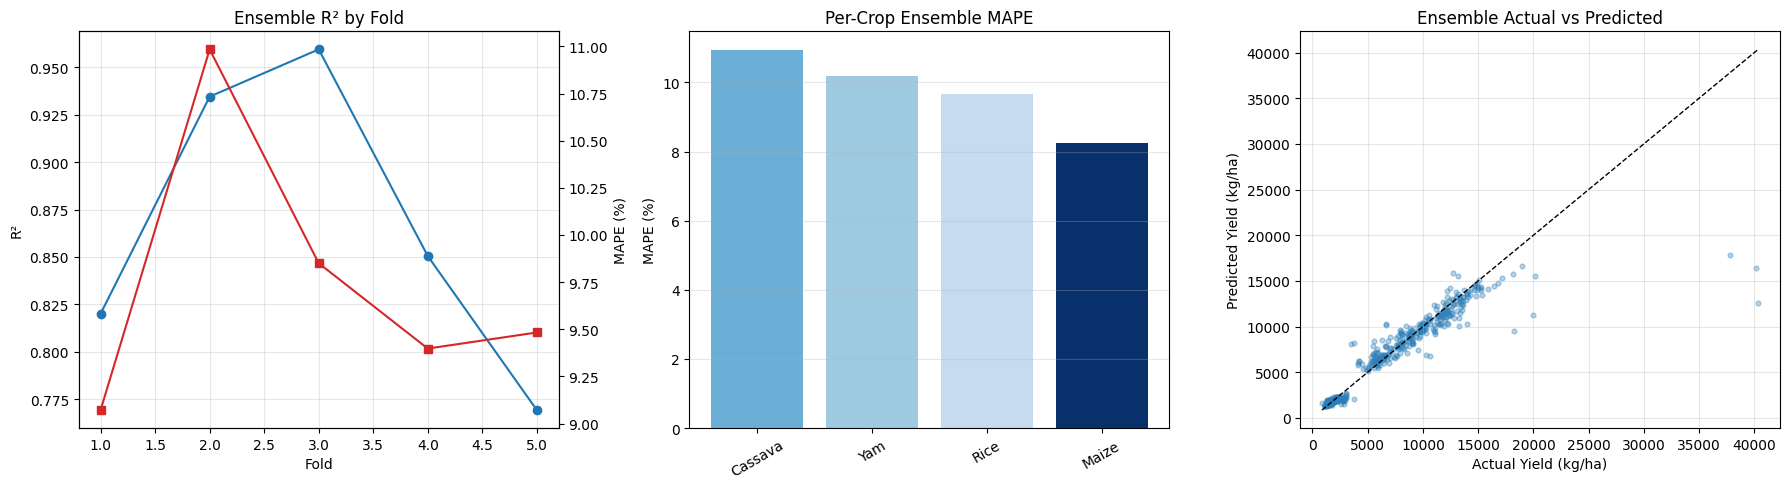

In [18]:
# Visualize ensemble results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Fold-level ensemble metrics
axes[0].plot(ensemble_mape_df['Fold'], ensemble_mape_df['Ensemble_R2'], marker='o', label='R²')
axes[0].set_title('Ensemble R² by Fold')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('R²')
axes[0].grid(alpha=0.3)

ax0b = axes[0].twinx()
ax0b.plot(ensemble_mape_df['Fold'], ensemble_mape_df['Ensemble_MAPE'], marker='s', color='tab:red', label='MAPE')
ax0b.set_ylabel('MAPE (%)')

# Per-crop MAPE comparison
crop_order = crop_perf_df.sort_values('Ens_MAPE', ascending=False)
axes[1].bar(crop_order['Crop'], crop_order['Ens_MAPE'], color=['#6baed6', '#9ecae1', '#c6dbef', '#08306b'])
axes[1].set_title('Per-Crop Ensemble MAPE')
axes[1].set_ylabel('MAPE (%)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)

# Actual vs predicted for all ensemble folds
all_true = np.concatenate([arr for _, arr in ensemble_all_y_true])
all_pred = np.concatenate([arr for _, arr in ensemble_all_y_pred])
axes[2].scatter(all_true, all_pred, s=12, alpha=0.35, color='#2c7fb8')
min_val = float(min(all_true.min(), all_pred.min()))
max_val = float(max(all_true.max(), all_pred.max()))
axes[2].plot([min_val, max_val], [min_val, max_val], '--', color='black', linewidth=1)
axes[2].set_title('Ensemble Actual vs Predicted')
axes[2].set_xlabel('Actual Yield (kg/ha)')
axes[2].set_ylabel('Predicted Yield (kg/ha)')
axes[2].grid(alpha=0.3)

fig.tight_layout()
plt.show()
